For this study, the Climate Change Twitter dataset was wrangled using Python and the Pandas library. The wrangling process involved data loading, removing duplicates, handling missing values, standardizing formats, extracting relevant features, and preparing the textual data for natural language processing.

### Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("The Climate Change Twitter Dataset.csv")

# Display first rows
df.head()

,created_at,id,lng,lat,topic,sentiment,stance,gender,temperature_avg,aggressiveness
0,2006-06-06 16:06:42+00:00,6132,NaN,NaN,Weather Extremes,-0.097180,neutral,female,NaN,aggressive
1,2006-07-23 21:52:30+00:00,13275,-73.949582,40.650104,Weather Extremes,0.575777,neutral,undefined,-1.114768,aggressive
2,2006-08-29 01:52:30+00:00,23160,NaN,NaN,Weather Extremes,0.500479,neutral,male,NaN,aggressive
3,2006-11-07 02:46:52+00:00,57868,NaN,NaN,Weather Extremes,0.032816,neutral,male,NaN,aggressive
4,2006-11-27 14:27:43+00:00,304553,NaN,NaN,Importance of Human Intervantion,-0.090428,neutral,male,NaN,aggressive


### Checking Dataset Structure

In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15789411 entries, 0 to 15789410
Data columns (total 10 columns):
 #   Column           Dtype  
---  ------           -----  
 0   created_at       object 
 1   id               int64  
 2   lng              float64
 3   lat              float64
 4   topic            object 
 5   sentiment        float64
 6   stance           object 
 7   gender           object 
 8   temperature_avg  float64
 9   aggressiveness   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 1.2+ GB


,id,lng,lat,sentiment,temperature_avg
count,1.578941e+07,5.307538e+06,5.307538e+06,1.578941e+07,5.307538e+06
mean,8.459853e+17,-4.639117e+01,3.408025e+01,2.536663e-03,1.245156e+00
std,3.113522e+17,7.523162e+01,2.229430e+01,4.379192e-01,3.799786e+00
min,6.132000e+03,-1.796670e+02,-9.000000e+01,-9.942049e-01,-2.328904e+01
25%,7.354169e+17,-9.536327e+01,3.315067e+01,-3.957429e-01,-1.140978e+00
50%,9.564851e+17,-7.703637e+01,3.995233e+01,-2.328273e-03,1.211522e+00
75%,1.049540e+18,-1.483154e-01,4.550884e+01,4.161248e-01,3.867153e+00
max,1.178912e+18,1.793830e+02,8.500000e+01,9.917458e-01,2.100350e+01


### Removing Duplicate Tweets

In [3]:
df = df.drop_duplicates(subset='id')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15789411 entries, 0 to 15789410
Data columns (total 10 columns):
 #   Column           Dtype  
---  ------           -----  
 0   created_at       object 
 1   id               int64  
 2   lng              float64
 3   lat              float64
 4   topic            object 
 5   sentiment        float64
 6   stance           object 
 7   gender           object 
 8   temperature_avg  float64
 9   aggressiveness   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 1.2+ GB


### Handling Missing Values

In [4]:
# Check missing values
df.isnull().sum()


created_at                0
id                        0
lng                10481873
lat                10481873
topic                     0
sentiment                 0
stance                    0
gender                    0
temperature_avg    10481873
aggressiveness            0
dtype: int64

In [5]:

# remove rows with missing key variables
df = df.dropna(subset=['stance','sentiment'])

# fill missing temperature values
df['temperature_avg'] = df['temperature_avg'].fillna(df['temperature_avg'].mean())

### Converting Timestamp Format

In [6]:
df['created_at'] = pd.to_datetime(df['created_at'])

df['year'] = df['created_at'].dt.year
df['month'] = df['created_at'].dt.month

### Validating Geographic Data

In [7]:
df['gender'] = df['gender'].astype('category')
df['topic'] = df['topic'].astype('category')
df['stance'] = df['stance'].astype('category')
df['aggressiveness'] = df['aggressiveness'].astype('category')

In [8]:
df.head()

,created_at,id,lng,lat,topic,sentiment,stance,gender,temperature_avg,aggressiveness,year,month
0,2006-06-06 16:06:42+00:00,6132,NaN,NaN,Weather Extremes,-0.097180,neutral,female,1.245156,aggressive,2006,6
1,2006-07-23 21:52:30+00:00,13275,-73.949582,40.650104,Weather Extremes,0.575777,neutral,undefined,-1.114768,aggressive,2006,7
2,2006-08-29 01:52:30+00:00,23160,NaN,NaN,Weather Extremes,0.500479,neutral,male,1.245156,aggressive,2006,8
3,2006-11-07 02:46:52+00:00,57868,NaN,NaN,Weather Extremes,0.032816,neutral,male,1.245156,aggressive,2006,11
4,2006-11-27 14:27:43+00:00,304553,NaN,NaN,Importance of Human Intervantion,-0.090428,neutral,male,1.245156,aggressive,2006,11


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15789411 entries, 0 to 15789410
Data columns (total 12 columns):
 #   Column           Dtype              
---  ------           -----              
 0   created_at       datetime64[ns, UTC]
 1   id               int64              
 2   lng              float64            
 3   lat              float64            
 4   topic            category           
 5   sentiment        float64            
 6   stance           category           
 7   gender           category           
 8   temperature_avg  float64            
 9   aggressiveness   category           
 10  year             int32              
 11  month            int32              
dtypes: category(4), datetime64[ns, UTC](1), float64(4), int32(2), int64(1)
memory usage: 903.5 MB


### Feature Selection

In [10]:
df = df[['created_at','year','month','lat','lng','topic','sentiment','stance','gender','temperature_avg','aggressiveness']]

### Saving the Clean Dataset

In [11]:
df.to_csv("clean_climate_data.csv", index=False)

## Descriptive Analytics

Descriptive analytics focuses on summarizing and visualizing data to understand its main characteristics and patterns. It provides insights into the distribution, central tendencies, and variability of variables within the dataset. In the context of the Climate Change Twitter dataset, descriptive analytics helps identify patterns in public sentiment, stance on climate change, geographical distribution of tweets, and relationships between environmental factors such as temperature and user sentiment.

### Summary Statistics

In [12]:
df.describe()

,year,month,lat,lng,sentiment,temperature_avg
count,1.578941e+07,1.578941e+07,5.307538e+06,5.307538e+06,1.578941e+07,1.578941e+07
mean,2.016639e+03,7.024364e+00,3.408025e+01,-4.639117e+01,2.536663e-03,1.245156e+00
std,2.514086e+00,3.647454e+00,2.229430e+01,7.523162e+01,4.379192e-01,2.203042e+00
min,2.006000e+03,1.000000e+00,-9.000000e+01,-1.796670e+02,-9.942049e-01,-2.328904e+01
25%,2.016000e+03,4.000000e+00,3.315067e+01,-9.536327e+01,-3.957429e-01,1.245156e+00
50%,2.018000e+03,7.000000e+00,3.995233e+01,-7.703637e+01,-2.328273e-03,1.245156e+00
75%,2.018000e+03,1.000000e+01,4.550884e+01,-1.483154e-01,4.161248e-01,1.245156e+00
max,2.019000e+03,1.200000e+01,8.500000e+01,1.793830e+02,9.917458e-01,2.100350e+01


### Distribution of Sentiment Scores

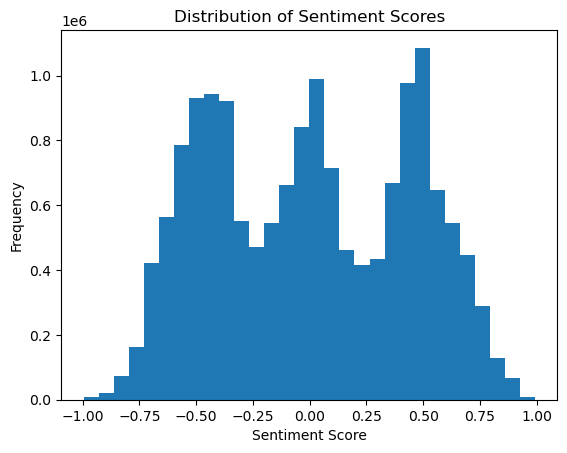

In [13]:

plt.hist(df['sentiment'], bins=30)
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

### Stance Distribution

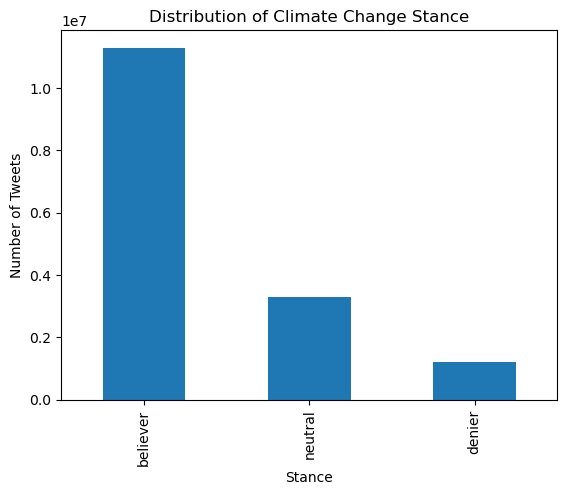

In [14]:
df['stance'].value_counts().plot(kind='bar')

plt.title("Distribution of Climate Change Stance")
plt.xlabel("Stance")
plt.ylabel("Number of Tweets")
plt.show()

### Gender Distribution

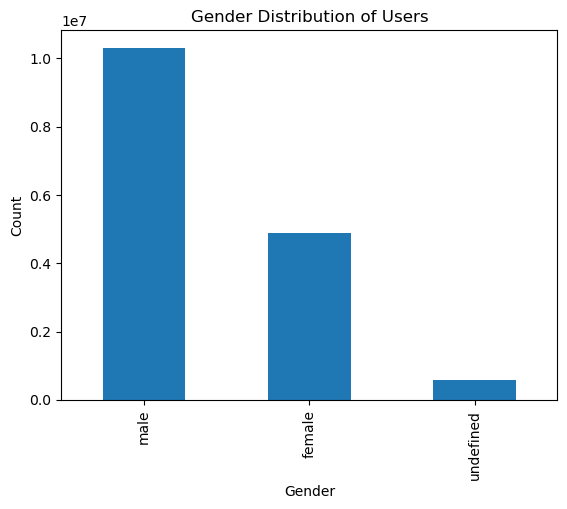

In [15]:
df['gender'].value_counts().plot(kind='bar')

plt.title("Gender Distribution of Users")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

### Sentiment vs Temperature

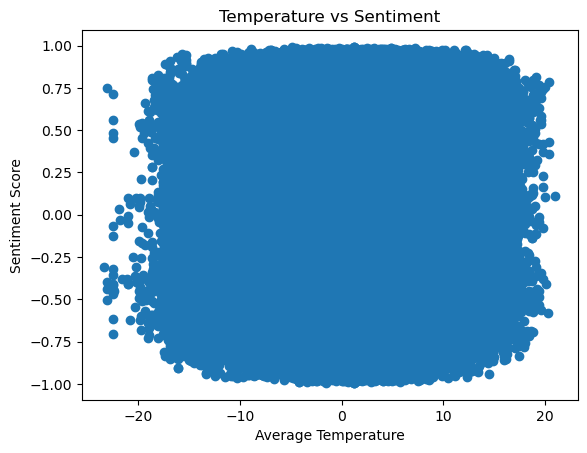

In [16]:
plt.scatter(df['temperature_avg'], df['sentiment'])

plt.title("Temperature vs Sentiment")
plt.xlabel("Average Temperature")
plt.ylabel("Sentiment Score")
plt.show()

### Climate Discussion Trends Over Time

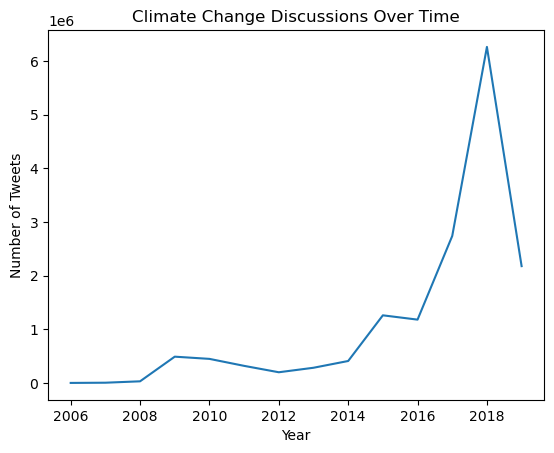

In [17]:
tweets_per_year = df['year'].value_counts().sort_index()

tweets_per_year.plot(kind='line')

plt.title("Climate Change Discussions Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Tweets")
plt.show()

### Topic Distribution

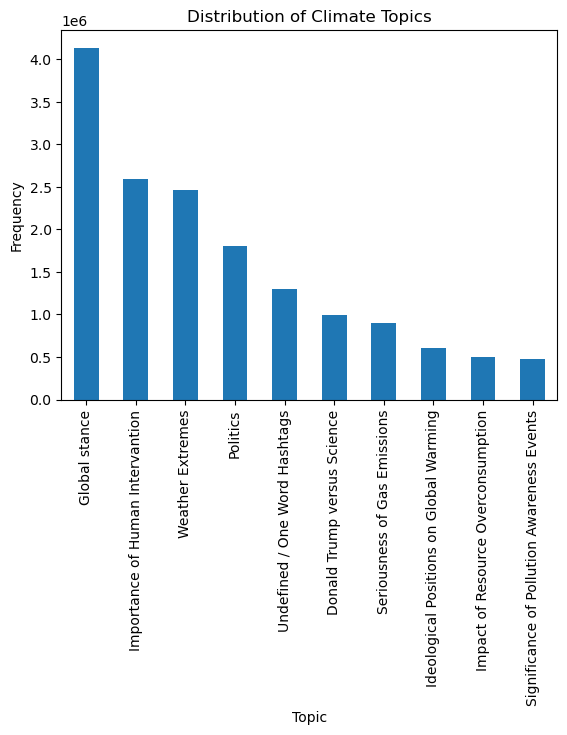

In [18]:
df['topic'].value_counts().plot(kind='bar')

plt.title("Distribution of Climate Topics")
plt.xlabel("Topic")
plt.ylabel("Frequency")
plt.show()

### Aggressiveness Distribution

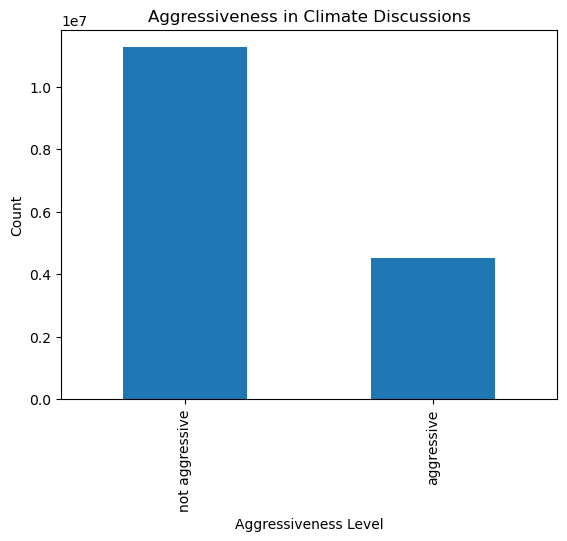

In [19]:
df['aggressiveness'].value_counts().plot(kind='bar')

plt.title("Aggressiveness in Climate Discussions")
plt.xlabel("Aggressiveness Level")
plt.ylabel("Count")
plt.show()

## Predictive Analytics

Predictive analytics involves using machine learning techniques to forecast outcomes based on historical data. In this study, multiple classification algorithms were implemented to predict the stance of Twitter users toward climate change. Using several models allows for comparison of performance and helps identify the most accurate algorithm for the dataset.

Three classification models were implemented: Logistic Regression, Random Forest, and Support Vector Machine (SVM). These models were evaluated using performance metrics including accuracy, precision, recall, F1-score, and ROC curve analysis.

### Feature Selection

### Encode Target Variable

In [40]:
from sklearn.preprocessing import LabelEncoder

le_topic = LabelEncoder()
le_gender = LabelEncoder()
le_aggr = LabelEncoder()
le_stance = LabelEncoder()

df['topic_enc'] = le_topic.fit_transform(df['topic'])
df['gender_enc'] = le_gender.fit_transform(df['gender'])
df['aggr_enc'] = le_aggr.fit_transform(df['aggressiveness'])

# Ensure the target variable is numeric encoded for modeling (creates it if it does not already exist)
df['stance_encoded'] = le_stance.fit_transform(df['stance'])

In [41]:
features = df[['sentiment','temperature_avg','topic','gender','aggressiveness']]
target = df['stance_encoded']

### Train-Test Split

In [42]:
from sklearn.model_selection import train_test_split

# Downsample for memory efficiency (avoids MemoryError during model training)
sample_size = min(200000, len(df))
df_sample = df.sample(sample_size, random_state=42)

features = df_sample[['sentiment','temperature_avg','topic_enc','gender_enc','aggr_enc']]
target = df_sample['stance_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.3, random_state=42
)

print('Sample size:', sample_size)
print('Train shape:', X_train.shape, y_train.shape)
print('Test shape:', X_test.shape, y_test.shape)

Sample size: 200000
Train shape: (140000, 5) (140000,)
Test shape: (60000, 5) (60000,)


### Model 1 - Logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

### Model 2 - Random Forest

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

### Model 3 - Gradient Boosting

In [45]:
from sklearn.ensemble import GradientBoostingClassifier

# Train a gradient boosting model which often handles class imbalance and non-linear relationships better than a linear SVM.
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

### Evaluate Models

In [46]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

print("y_test class distribution (important to understand class imbalance):")
print(y_test.value_counts(normalize=True).sort_index())
print()

model_preds = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred,
    "SVM": svm_pred,
}

results = []
for name, preds in model_preds.items():
    acc = accuracy_score(y_test, preds)
    prec_w = precision_score(y_test, preds, average="weighted", zero_division=0)
    rec_w = recall_score(y_test, preds, average="weighted", zero_division=0)
    f1_w = f1_score(y_test, preds, average="weighted", zero_division=0)

    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted precision: {prec_w:.4f}")
    print(f"Weighted recall: {rec_w:.4f}")
    print(f"Weighted f1: {f1_w:.4f}")
    print("Classification report:")
    print(classification_report(y_test, preds, zero_division=0))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, preds))
    print()

    results.append(
        {
            "model": name,
            "accuracy": acc,
            "precision_w": prec_w,
            "recall_w": rec_w,
            "f1_w": f1_w,
        }
    )

summary = pd.DataFrame(results).sort_values("f1_w", ascending=False).reset_index(drop=True)
print("Summary comparison (sorted by weighted F1):")
print(summary)

# Feature importance for tree models is important for interpretability
print()
print("Feature importances (tree-based models):")
for model_name, model_obj in [("Random Forest", rf), ("Gradient Boosting", gb)]:
    print(model_name, ":", dict(zip(X_test.columns, model_obj.feature_importances_)))

y_test class distribution (important to understand class imbalance):
stance_encoded
0    0.716250
1    0.076383
2    0.207367
Name: proportion, dtype: float64

=== Logistic Regression ===
Accuracy: 0.7163
Weighted precision: 0.5130
Weighted recall: 0.7163
Weighted f1: 0.5978
Classification report:
              precision    recall  f1-score   support

           0       0.72      1.00      0.83     42975
           1       0.00      0.00      0.00      4583
           2       0.00      0.00      0.00     12442

    accuracy                           0.72     60000
   macro avg       0.24      0.33      0.28     60000
weighted avg       0.51      0.72      0.60     60000

Confusion matrix:
[[42975     0     0]
 [ 4583     0     0]
 [12442     0     0]]

=== Random Forest ===
Accuracy: 0.7372
Weighted precision: 0.7020
Weighted recall: 0.7372
Weighted f1: 0.6689
Classification report:
              precision    recall  f1-score   support

           0       0.75      0.97      0.84     4

In [47]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

model_preds = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred,
}

rows = []
for name, preds in model_preds.items():
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_precision": report["weighted avg"]["precision"],
        "weighted_recall": report["weighted avg"]["recall"],
        "weighted_f1": report["weighted avg"]["f1-score"],
    })
    print(f"\n=== {name} classification report ===")
    print(classification_report(y_test, preds, zero_division=0))

summary_df = pd.DataFrame(rows).sort_values("macro_f1", ascending=False)
display(summary_df)

print("GB class counts:", np.unique(gb_pred, return_counts=True))


=== Logistic Regression classification report ===
              precision    recall  f1-score   support

           0       0.72      1.00      0.83     42975
           1       0.00      0.00      0.00      4583
           2       0.00      0.00      0.00     12442

    accuracy                           0.72     60000
   macro avg       0.24      0.33      0.28     60000
weighted avg       0.51      0.72      0.60     60000


=== Random Forest classification report ===
              precision    recall  f1-score   support

           0       0.75      0.97      0.84     42975
           1       0.53      0.02      0.04      4583
           2       0.61      0.19      0.29     12442

    accuracy                           0.74     60000
   macro avg       0.63      0.40      0.39     60000
weighted avg       0.70      0.74      0.67     60000


=== Gradient Boosting classification report ===
              precision    recall  f1-score   support

           0       0.75      0.98     

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
1,Random Forest,0.737217,0.629906,0.395470,0.393424,0.702023,0.737217,0.668899
2,Gradient Boosting,0.740283,0.676949,0.393624,0.389827,0.719024,0.740283,0.668656
0,Logistic Regression,0.716250,0.238750,0.333333,0.278223,0.513014,0.716250,0.597831


GB class counts: (array([0, 1, 2]), array([56390,   124,  3486], dtype=int64))


### Confusion Matrix

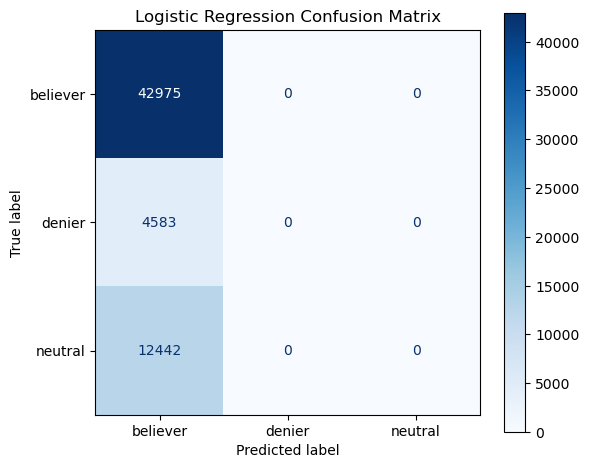

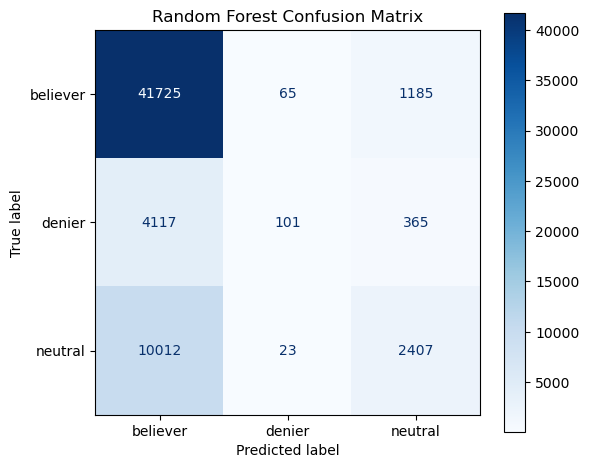

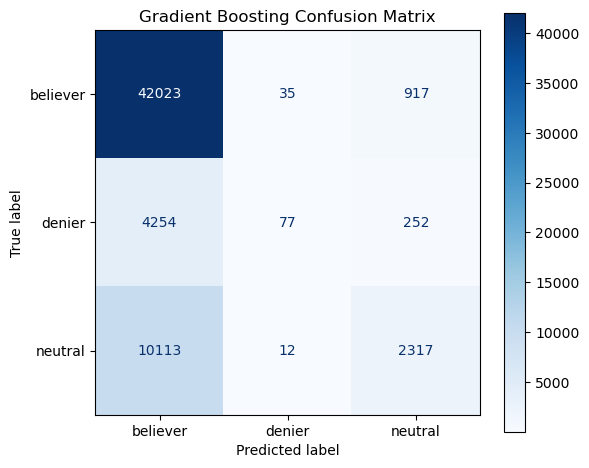

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model_preds = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred,
    
}

for model_name, preds in model_preds.items():
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=le_stance.classes_  # assumes target encoder has classes
    )
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(cmap="Blues", values_format="d", ax=ax)
    ax.set_title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

### ROC Curve

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

import matplotlib.pyplot as plt

# binarize one-vs-rest labels
y_test_bin = label_binarize(y_test, classes=np.arange(len(le_stance.classes_)))
n_classes = y_test_bin.shape[1]

model_probas = {
    "Logistic Regression": lr.predict_proba(X_test),
    "Random Forest": rf.predict_proba(X_test),
    "Gradient Boosting": gb.predict_proba(X_test),
    "SVM": svm.predict_proba(X_test),
}

for model_name, proba in model_probas.items():
    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # micro-average ROC curve and AUC
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), proba.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # macro-average ROC curve and AUC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes

    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr["micro"],
        tpr["micro"],
        label=f"micro-average ROC (AUC = {roc_auc['micro']:.3f})",
        color="deeppink",
        linestyle=":",
        linewidth=2,
    )
    plt.plot(
        fpr["macro"],
        tpr["macro"],
        label=f"macro-average ROC (AUC = {roc_auc['macro']:.3f})",
        color="navy",
        linestyle=":",
        linewidth=2,
    )

    for i, class_label in enumerate(le_stance.classes_):
        plt.plot(
            fpr[i],
            tpr[i],
            label=f"{class_label} (AUC = {roc_auc[i]:.3f})",
            linewidth=1.5,
        )

    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} ROC Curves (multiclass)")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()